In [1]:
%pip install datasets

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import nltk
from nltk import pos_tag
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
import os

NLTK_DATA_DIR = os.path.join(os.getcwd(), "nltk_data")
os.makedirs(NLTK_DATA_DIR, exist_ok=True)
nltk.data.path.insert(0, NLTK_DATA_DIR)

required_resources = {
    "tokenizers/punkt_tab": "punkt_tab",
    "corpora/stopwords": "stopwords",
    "taggers/averaged_perceptron_tagger_eng": "averaged_perceptron_tagger_eng",
    "corpora/wordnet": "wordnet",
}

for path, resource_name in required_resources.items():
    try:
        nltk.data.find(path)
        print(f"✓ {resource_name} already available")
    except LookupError:
        try:
            nltk.download(resource_name, download_dir=NLTK_DATA_DIR)
            print(f"✓ {resource_name} downloaded")
        except Exception as e:
            print(f"✗ {resource_name} failed to download: {e}")

✓ punkt_tab already available
✓ stopwords already available
✓ averaged_perceptron_tagger_eng already available
✓ wordnet downloaded


[nltk_data] Downloading package wordnet to C:\Users\ADMIN\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


# Sentiment Analysis of Nigerian Mobile Banking App Reviews

## Dataset Loading

The dataset used for this project is the Nigerian Bank App Reviews
Dataset from the Federal University Lokoja on Hugging Face.

The dataset contains customer reviews of Nigerian banking applications,
their corresponding ratings, and the year of the review.

The original bank files were loaded individually and combined
into a single dataset. A `bank` column was retained to identify the
bank associated with each review.

In [3]:
from huggingface_hub import hf_hub_download
import pandas as pd

# Map each bank name to its original CSV filename
bank_files = {
    "Access Bank": "access_reviews.csv",
    "EcoBank": "ecoBank_reviews.csv",
    "First Bank of Nigeria": "fbn_reviews.csv",
    "FCMB": "fcmb_reviews.csv",
    "Fidelity Bank": "fidelityBank_reviews.csv",
    "GTBank": "gtb_reviews.csv",
    "Jaiz Bank": "jaizBank_reviews.csv",
    "Keystone Bank": "keyStoneBank_reviews.csv",
    "Polaris Bank": "polarisBank_reviews.csv",
    "Stanbic IBTC": "stanbicIbtc_reviews.csv",
    "Sterling Bank": "sterlingBank_reviews.csv",
    "UBA": "uba_reviews.csv",
    "Union Bank": "unionBank_reviews.csv",
    "Unity Bank": "unityBank_reviews.csv",
    "Wema Bank": "wemaBank_reviews.csv",
    "Zenith Bank": "zenithBank_reviews.csv"
}

# Create an empty list to temporarily store each bank's DataFrame
bank_dfs = []

# Load each bank's file
for bank, filename in bank_files.items():

    # Download the original CSV file from the Hugging Face dataset repository
    file_path = hf_hub_download(
        repo_id="Federal-University-Lokoja/Bank-Review",
        filename=filename,
        repo_type="dataset"
    )

    # Read the CSV file into a pandas DataFrame
    bank_df = pd.read_csv(file_path)

    # Add the bank name so we do not lose its identity
    bank_df["bank"] = bank

    # Store the bank's DataFrame in the list
    bank_dfs.append(bank_df)

# Combine all 16 bank DataFrames into one DataFrame
combined_df = pd.concat(bank_dfs, ignore_index=True)

# Display the dimensions of the combined dataset
print("Combined dataset shape:", combined_df.shape)

# Display the column names
print("\nColumns:")
print(combined_df.columns.tolist())

C:\Users\ADMIN\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Combined dataset shape: (334415, 4)

Columns:
['year', 'content', 'score', 'bank']


In [4]:
print("Number of banks:", combined_df["bank"].nunique())

print("\nBanks:")
print(sorted(combined_df["bank"].unique()))

print("\nReviews per bank:")
print(combined_df["bank"].value_counts())

Number of banks: 16

Banks:
['Access Bank', 'EcoBank', 'FCMB', 'Fidelity Bank', 'First Bank of Nigeria', 'GTBank', 'Jaiz Bank', 'Keystone Bank', 'Polaris Bank', 'Stanbic IBTC', 'Sterling Bank', 'UBA', 'Union Bank', 'Unity Bank', 'Wema Bank', 'Zenith Bank']

Reviews per bank:
bank
UBA                      87609
Access Bank              50204
Stanbic IBTC             45094
First Bank of Nigeria    33607
Zenith Bank              20959
Wema Bank                20175
EcoBank                  17442
GTBank                   14147
FCMB                     12006
Union Bank                9293
Sterling Bank             7974
Polaris Bank              6100
Keystone Bank             3978
Fidelity Bank             3703
Jaiz Bank                 1197
Unity Bank                 927
Name: count, dtype: int64


In [5]:
df = combined_df.copy()

##  Data Inspection

Before cleaning or preprocessing the reviews, the dataset is examined to understand its structure, data types, missing values, duplicate records, and rating distribution.

This step helps identify potential data quality issues that need to be addressed before sentiment classification.

In [6]:
df.head()

,year,content,score,bank
0,2024,this app is so amazing😍😍🤩🤩,1,Access Bank
1,2024,perfect,5,Access Bank
2,2024,Impressive and Amazing,4,Access Bank
3,2024,it is difficult to swipe to preferred host acc...,3,Access Bank
4,2024,great,5,Access Bank


In [7]:
# Display the structure, data types, and non-null counts of the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 334415 entries, 0 to 334414
Data columns (total 4 columns):
 #   Column   Non-Null Count   Dtype
---  ------   --------------   -----
 0   year     334415 non-null  int64
 1   content  334292 non-null  str  
 2   score    334415 non-null  int64
 3   bank     334415 non-null  str  
dtypes: int64(2), str(2)
memory usage: 34.0 MB


### Checking for Missing Values

Missing values can affect data analysis and machine learning models. Since the `content` column contains the text that will be used for sentiment classification, missing review text cannot be directly processed by the text-analysis pipeline.

The missing values are identified and examined before deciding whether they should be removed or handled in another way.

In [8]:
# Count the number of missing values in each column
missing_values = df.isnull().sum()

# Display the missing-value count
print(missing_values)

year         0
content    123
score        0
bank         0
dtype: int64


### Inspecting Missing Review Records

Because the sentiment model requires review text, records with no usable text will eventually be excluded from the modeling dataset. However, this decision is made only after inspecting the affected records.

In [9]:
# Select records where the review text is missing
missing_content = df[df["content"].isnull()]

# Display the affected records
missing_content

,year,content,score,bank
10237,2023,NaN,5,Access Bank
50242,2023,NaN,5,EcoBank
67739,2023,NaN,5,First Bank of Nigeria
83411,2021,NaN,5,First Bank of Nigeria
88270,2020,NaN,4,First Bank of Nigeria
...,...,...,...,...
333924,2015,NaN,3,Zenith Bank
334181,2015,NaN,5,Zenith Bank
334184,2015,NaN,5,Zenith Bank
334359,2014,NaN,5,Zenith Bank


### Handling Missing Review Text

Since the `content` column contains the text required for sentiment analysis, records without review text cannot be used by the text-processing and machine-learning pipeline.

The 123 records with missing review text are therefore removed from the modeling dataset. The original DataFrame is preserved, while a separate cleaned DataFrame is created for subsequent analysis.

In [10]:
# Remove rows where the review text is missing
df_clean = df.dropna(subset=["content"]).copy()

# Reset the index after removing the missing text records
df_clean.reset_index(drop=True, inplace=True)

# Display the new dataset dimensions
print("Cleaned dataset shape:", df_clean.shape)

Cleaned dataset shape: (334292, 4)


In [11]:
# Check for missing values in the cleaned dataset
df_clean.isnull().sum()

year       0
content    0
score      0
bank       0
dtype: int64

### Checking for Duplicate Records
Duplicate records are identified before model development because identical observations can contribute to overly optimistic evaluation if they are split between the training and testing sets.


In [12]:
# Count duplicate rows across all columns
duplicate_count = df_clean.duplicated().sum()

# Display the number of duplicate records
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 74962


### Inspecting Duplicate Records


In [13]:
# Display examples of duplicate records
duplicates = df_clean[df_clean.duplicated(keep=False)]

# Sort duplicates so identical records appear together
duplicates = duplicates.sort_values(
    by=["bank", "year", "content", "score"]
)

# Display the first 20 duplicate records
duplicates.head(20)

,year,content,score,bank
49048,2020,Amazing,5,Access Bank
49343,2020,Amazing,5,Access Bank
48911,2020,Awesome,5,Access Bank
48965,2020,Awesome,5,Access Bank
49345,2020,Awesome,5,Access Bank
49552,2020,Awesome,5,Access Bank
49622,2020,Awesome,5,Access Bank
49867,2020,Awesome,5,Access Bank
49885,2020,Awesome,5,Access Bank
49910,2020,Awesome,5,Access Bank


### Exact Duplicate Handling

Very short reviews such as “Amazing,” “Good,” and “Excellent” are common in app-store review data and may represent independent customer submissions. Therefore, reviews containing fewer than five words are retained even when repeated. For reviews containing five or more words, exact duplicates are reduced to one occurrence based on the year, review text, rating, and bank. This approach preserves short customer expressions while reducing the influence of repeated longer reviews.


In [14]:
# Reconstruct the pre-dedup state from the untouched original df
df_clean_before_dedup = df.dropna(subset=["content"]).copy()

before_dedup_pct = (
    df_clean_before_dedup["score"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)
print(before_dedup_pct)

score
1    25.74
2     5.08
3     6.65
4    11.19
5    51.34
Name: proportion, dtype: float64


In [15]:
# Check word count distribution of the rows found as duplicates
duplicates = df_clean_before_dedup[
    df_clean_before_dedup.duplicated(subset=["year", "content", "score", "bank"], keep=False)
]
duplicates["word_count"] = duplicates["content"].str.split().str.len()
print(duplicates["word_count"].describe())
print(duplicates["word_count"].value_counts().sort_index().head(15))

count    86224.000000
mean         1.544616
std          0.954021
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max         73.000000
Name: word_count, dtype: float64
word_count
1     53315
2     23579
3      5981
4      2541
5       614
6       160
7        15
8         4
9         2
12        2
16        3
20        2
25        2
55        2
73        2
Name: count, dtype: int64


In [16]:
# Create a fresh copy of the dataset after missing review text was removed
df_clean = df.dropna(subset=["content"]).copy()

# Calculate the number of words in each review
df_clean["word_count"] = df_clean["content"].str.split().str.len()

# Keep short reviews unchanged because they may have been independently submitted
short_reviews = df_clean[df_clean["word_count"] < 5]

# Select longer reviews for exact duplicate removal
long_reviews = df_clean[df_clean["word_count"] >= 5]

# Remove exact duplicates among longer reviews
long_reviews_deduped = long_reviews.drop_duplicates(
    subset=["year", "content", "score", "bank"],
    keep="first"
)

# Combine the retained short reviews with the deduplicated longer reviews
df_clean = pd.concat(
    [short_reviews, long_reviews_deduped],
    ignore_index=True
)

# Reset the index after duplicate handling
df_clean.reset_index(drop=True, inplace=True)

# Display the resulting dataset dimensions
print("Dataset shape after duplicate handling:", df_clean.shape)

Dataset shape after duplicate handling: (333821, 5)


### Checking Rating Distribution After Cleaning

The `score` variable represents the star rating assigned to each customer review, ranging from 1 to 5.

Before converting these ratings into sentiment categories, the distribution of ratings is examined to understand the balance of the data and identify any notable skew.

In [17]:
# Count the number of reviews for each star rating
score_distribution = df_clean["score"].value_counts().sort_index()

# Display the rating distribution
print(score_distribution)

score
1     86004
2     16990
3     22212
4     37386
5    171229
Name: count, dtype: int64


### Rating Distribution by Percentage

The percentage distribution of the star ratings is calculated to assess the extent of any imbalance in the ratings before sentiment labels are created.

In [18]:
# Calculate the percentage of reviews for each star rating
score_percentage = (
    df_clean["score"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

# Display the percentage distribution
print(score_percentage.round(2))

score
1    25.76
2     5.09
3     6.65
4    11.20
5    51.29
Name: proportion, dtype: float64


### Expected Sentiment Class Distribution

The 1–5 star ratings are grouped into three sentiment categories:

- Ratings 1–2 are classified as Negative.
- Rating 3 is classified as Neutral.
- Ratings 4–5 are classified as Positive.

The resulting class distribution is examined before the sentiment labels are added to the dataset.

In [19]:
# Group the ratings into the three sentiment categories
sentiment_distribution = pd.cut(
    df_clean["score"],
    bins=[0, 2, 3, 5],
    labels=["Negative", "Neutral", "Positive"]
).value_counts().sort_index()

# Display the number of reviews in each sentiment category
print(sentiment_distribution)

score
Negative    102994
Neutral      22212
Positive    208615
Name: count, dtype: int64



### Creating Sentiment Labels

Because the dataset does not provide explicit sentiment labels, sentiment categories are derived from the customer rating: 1–2 stars are treated as Negative, 3 stars as Neutral, and 4–5 stars as Positive

In [20]:
df_clean["rating_derived_sentiment"] = pd.cut(
    df_clean["score"],
    bins=[0, 2, 3, 5],
    labels=["Negative", "Neutral", "Positive"]
)

print(df_clean["rating_derived_sentiment"].value_counts())

rating_derived_sentiment
Positive    208615
Negative    102994
Neutral      22212
Name: count, dtype: int64


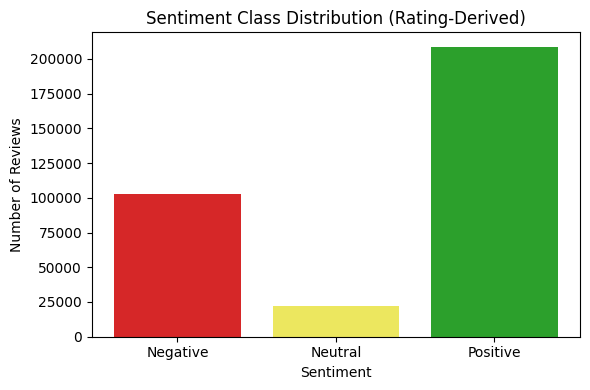

In [21]:
import matplotlib.pyplot as plt

# Visualize the class distribution computed above
sentiment_counts = df_clean["rating_derived_sentiment"].value_counts().reindex(
    ["Negative", "Neutral", "Positive"]
)

plt.figure(figsize=(6, 4))
plt.bar(sentiment_counts.index, sentiment_counts.values, color=["#d62728", "#ece75f", "#2ca02c"])
plt.title("Sentiment Class Distribution (Rating-Derived)")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.show()

### Checking for Empty Review Text


In [22]:
# Check for reviews that are empty or contain only whitespace
empty_content = df_clean["content"].str.strip().eq("").sum()

# Display the number of empty or whitespace-only reviews
print("Number of empty reviews:", empty_content)

Number of empty reviews: 0


### Inspecting Raw Review Text

Examined to understand the characteristics of the raw text.

This helps identify features such as capitalization, punctuation, emojis, numbers, and informal language that may need to be considered during preprocessing.

In [23]:
# Display a random sample of 10 reviews from the dataset
df_clean["content"].sample(10, random_state=42).tolist()

['Very nice',
 "Been trying multiple times but for some reasons, this app isn't installing....",
 "I can't open the app, what wrong? It frustrating. Please work on it",
 'Horrible inferior app ever',
 'cool',
 'intuitive and easy to interact with.',
 "This is the worst app ever, sometimes it works very well, sometimes it won't open at all despite the Stable Network. Pls rectify this ASAP",
 'Excellent',
 "The app is not working it's says the service is currently unavailable please try again later while we investigate it's been 2 months now",
 "The qpp is the worst i want to put a new phone number to my ATM card but it will not work don't just no wat to do"]

### Handling Contractions, Emojis, Punctuation, and Whitespace

Customer reviews contain several forms of text variation that can affect
text machine-learning models, including contractions, punctuation,
emojis, and inconsistent spacing.

Contractions such as "can't", "don't", and "it's" are expanded before
punctuation is removed so that important words, particularly negations,
are not lost.

Emojis are converted into descriptive text rather than being discarded,
because they can provide useful sentiment information.

Punctuation that does not contribute directly to the textual meaning is
then removed, while letters, numbers, underscores, and whitespace are
retained.
The processed text is stored in the `cleaned_text` column, while the
original `content` column is preserved for reference and later error
analysis.

In [24]:
%pip install emoji

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [25]:
%pip install contractions


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [26]:
import contractions
import emoji
import re

# Define a function for the main text cleaning
def clean_text(text):
    # Expand contractions such as "can't" to "cannot"
    text = contractions.fix(text)

    # Convert emojis into descriptive text
    text = emoji.demojize(text, delimiters=(" ", " "))

    # Remove punctuation while preserving letters, numbers, underscores, and spaces
    text = re.sub(r"[^\w\s]", "", text, flags=re.UNICODE)

    # Replace multiple spaces with a single space
    text = re.sub(r"\s+", " ", text)

    # Remove unnecessary spaces from the beginning and end
    return text.strip()

# Applying Lowercase so the final text is consistently normalized
df_clean["cleaned_text"] = (
    df_clean["content"]
    .str.lower()
    .apply(clean_text)
)

# Display the original and cleaned text for the first five reviews
df_clean[["content", "cleaned_text"]].head()

,content,cleaned_text
0,perfect,perfect
1,Impressive and Amazing,impressive and amazing
2,great,great
3,world best bank ever,world best bank ever
4,good,good


In [27]:
# Display selected reviews in full to verify contraction and emoji handling
for index in [0, 10, 20, 30, 40]:
    print(f"Review {index}")
    print("Original:", df_clean.loc[index, "content"])
    print("Cleaned :", df_clean.loc[index, "cleaned_text"])
    print()

Review 0
Original: perfect
Cleaned : perfect

Review 10
Original: I love all features
Cleaned : i love all features

Review 20
Original: Good app 100%
Cleaned : good app 100

Review 30
Original: amazing
Cleaned : amazing

Review 40
Original: The best
Cleaned : the best



### Tokenization

Tokenization is the process of dividing text into smaller units called
tokens. In this project, the tokens will primarily represent individual
words or meaningful textual units within each customer review.

For example, the review "this app is amazing" can be represented as
["this", "app", "is", "amazing"].

Tokenization is necessary because subsequent preprocessing steps, such
as stopword handling and lemmatization, operate on individual tokens
rather than complete text strings.


In [28]:
%pip install nltk

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### Tokenizing the Reviews

The cleaned review text is divided into individual tokens using NLTK's
word tokenizer.


In [29]:
from nltk.tokenize import word_tokenize

# Tokenize each cleaned review into individual words or text units
df_clean["tokens"] = df_clean["cleaned_text"].apply(word_tokenize)

# Display the cleaned text and its corresponding tokens for the first five reviews
df_clean[["cleaned_text", "tokens"]].head()

,cleaned_text,tokens
0,perfect,[perfect]
1,impressive and amazing,"[impressive, and, amazing]"
2,great,[great]
3,world best bank ever,"[world, best, bank, ever]"
4,good,[good]


### Preparing the Stopword List

Stopwords are common words that occur frequently in natural language but
may provide limited information for distinguishing between documents.

In [30]:
# Load the English stopword list
english_stopwords = stopwords.words("english")

# Display the number of stopwords available
print("Number of English stopwords:", len(english_stopwords))

# Display the first 20 stopwords
print(english_stopwords[:20])

Number of English stopwords: 198
['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been']


### Creating a Customized Stopword List



In [31]:
from nltk.corpus import stopwords

# Load the standard English stopword list
english_stopwords = set(stopwords.words("english"))

# Words that should be preserved because they can express negation
negation_words = {
    "no",
    "nor",
    "not",
    "never",
    "cannot"
}

# Remove the important negation words from the stopword list
custom_stopwords = english_stopwords - negation_words

# Display the negation words that will be preserved
print("Negation words preserved:", sorted(negation_words))

# Display the number of stopwords in the customized list
print("Number of customized stopwords:", len(custom_stopwords))

Negation words preserved: ['cannot', 'never', 'no', 'nor', 'not']
Number of customized stopwords: 195


### Removing Stopwords from Tokenized Reviews

The customized stopword list is applied to the tokenized review text.

Common words that provide limited information for sentiment classification are removed, while the selected negation words are retained. This reduces unnecessary words in the text while preserving words that can affect sentiment meaning.

The original tokenized text is retained, and the filtered tokens are stored in a new column for further preprocessing.

In [32]:
# Remove customized stopwords from each tokenized review
df_clean["tokens_no_stopwords"] = df_clean["tokens"].apply(
    lambda tokens: [token for token in tokens if token not in custom_stopwords]
)

# Display the original tokens and the filtered tokens for the first five reviews
df_clean[["tokens", "tokens_no_stopwords"]].head()

,tokens,tokens_no_stopwords
0,[perfect],[perfect]
1,"[impressive, and, amazing]","[impressive, amazing]"
2,[great],[great]
3,"[world, best, bank, ever]","[world, best, bank, ever]"
4,[good],[good]


In [33]:
# Tag every review and check how often single-word reviews get tagged as noun by default
single_word_mask = df_clean["tokens_no_stopwords"].apply(len) == 1
single_word_sample = df_clean.loc[single_word_mask, "tokens_no_stopwords"].sample(20, random_state=42)

for tokens in single_word_sample:
    print(tokens, "->", pos_tag(tokens))

['wow'] -> [('wow', 'NN')]
['great'] -> [('great', 'JJ')]
['cooooool'] -> [('cooooool', 'NN')]
['excellent'] -> [('excellent', 'NN')]
['excellent'] -> [('excellent', 'NN')]
['handy'] -> [('handy', 'NN')]
['perfect'] -> [('perfect', 'NN')]
['good'] -> [('good', 'JJ')]
['lovely'] -> [('lovely', 'RB')]
['good'] -> [('good', 'JJ')]
['perfect'] -> [('perfect', 'NN')]
['okay'] -> [('okay', 'NN')]
['nice'] -> [('nice', 'JJ')]
['nice'] -> [('nice', 'JJ')]
['fast'] -> [('fast', 'NN')]
['good'] -> [('good', 'JJ')]
['wonderful'] -> [('wonderful', 'NN')]
['good'] -> [('good', 'JJ')]
['poor'] -> [('poor', 'JJ')]
['great'] -> [('great', 'JJ')]


In [34]:
# Test whether wrapping isolated words in minimal context fixes the noun-default problem
test_words = ["perfect", "wow", "cooooool", "excellent", "handy", "okay", "fast", "wonderful", "lovely"]

for word in test_words:
    wrapped = pos_tag(["it", "is", word])
    print(word, "->", wrapped[-1])

perfect -> ('perfect', 'JJ')
wow -> ('wow', 'JJ')
cooooool -> ('cooooool', 'JJ')
excellent -> ('excellent', 'JJ')
handy -> ('handy', 'JJ')
okay -> ('okay', 'JJ')
fast -> ('fast', 'JJ')
wonderful -> ('wonderful', 'JJ')
lovely -> ('lovely', 'RB')


In [35]:
import nltk
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()

In [36]:
from nltk.corpus import wordnet

def get_wordnet_pos(penn_tag):
    if penn_tag.startswith("J"):
        return wordnet.ADJ
    elif penn_tag.startswith("V"):
        return wordnet.VERB
    elif penn_tag.startswith("R"):
        return wordnet.ADV
    else:
        return wordnet.NOUN

### POS-Aware Lemmatization

Part-of-speech (POS) tags are used to help the lemmatizer identify the correct base form of each word. The original `tokens` are used for POS tagging rather than `tokens_no_stopwords` because the original review provides more grammatical context. For example, a word such as **"good"** on its own can be difficult for a POS tagger to classify correctly, while a phrase such as **"it is good"** provides clearer context and allows **"good"** to be identified as an adjective. After the POS tags are obtained, only the words retained in `tokens_no_stopwords` are lemmatized.

Single-word reviews require special handling because they contain very little grammatical context. For these reviews, a temporary phrase such as **"it is good"** is created only for POS tagging. The added words **"it"** and **"is"** are never added to the dataset or included in the final text. Only the POS tag assigned to the original review word is used.

POS tagging is not perfect for every short or context limited review. Words such as **"lovely"** or **"wow"** may sometimes receive an unexpected POS tag. This limitation is accepted because, in these cases, the POS tag does not change the resulting lemma when WordNet has no different base form to apply.

In [37]:
from collections import Counter

def lemmatize_tokens(tokens, tokens_no_stopwords):
    if len(tokens) == 1:
        tagged = pos_tag(["it", "is"] + tokens)
        tagged_tokens = [tagged[-1]]
    else:
        tagged_tokens = pos_tag(tokens)

    keep_counts = Counter(tokens_no_stopwords)
    lemmatized = []
    for word, tag in tagged_tokens:
        if keep_counts[word] > 0:
            lemmatized.append(lemmatizer.lemmatize(word, pos=get_wordnet_pos(tag)))
            keep_counts[word] -= 1

    return lemmatized

In [38]:
df_clean["lemmatized_tokens"] = df_clean.apply(
    lambda row: lemmatize_tokens(row["tokens"], row["tokens_no_stopwords"]),
    axis=1
)

df_clean[["tokens_no_stopwords", "lemmatized_tokens"]].sample(10, random_state=42)

,tokens_no_stopwords,lemmatized_tokens
118532,[nice],[nice]
163722,"[trying, multiple, times, reasons, app, not, i...","[try, multiple, time, reason, app, not, instal]"
182842,"[not, open, app, wrong, frustrating, please, w...","[not, open, app, wrong, frustrate, please, work]"
95963,"[horrible, inferior, app, ever]","[horrible, inferior, app, ever]"
126725,[cool],[cool]
165989,"[intuitive, easy, interact]","[intuitive, easy, interact]"
192766,"[worst, app, ever, sometimes, works, well, som...","[bad, app, ever, sometimes, work, well, someti..."
103200,[excellent],[excellent]
235993,"[app, not, working, says, service, currently, ...","[app, not, work, say, service, currently, unav..."
325248,"[qpp, worst, want, put, new, phone, number, at...","[qpp, bad, want, put, new, phone, number, atm,..."


In [39]:
group_sizes = df_clean["content"].str.lower().str.strip().value_counts()
print(group_sizes.head(10))
print("\nLargest group as % of dataset:", round(group_sizes.max() / len(df_clean) * 100, 2), "%")

content
good         18245
excellent     8100
very good     4960
great         4505
nice          3933
awesome       2865
nice app      2766
great app     2295
good app      2263
cool          1751
Name: count, dtype: int64

Largest group as % of dataset: 5.47 %


### WordClouds by Sentiment Class

To visually inspect which words are most frequent within each sentiment
category, a WordCloud is generated for each class using the lemmatized,
stopword-filtered tokens (`lemmatized_tokens`). This is the same text
representation used for TF-IDF, so the WordClouds reflect the actual
vocabulary the model will learn from, rather than raw, unprocessed text.

WordClouds are descriptive only: word size reflects frequency within
that class, not sentiment strength or importance to the model.


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


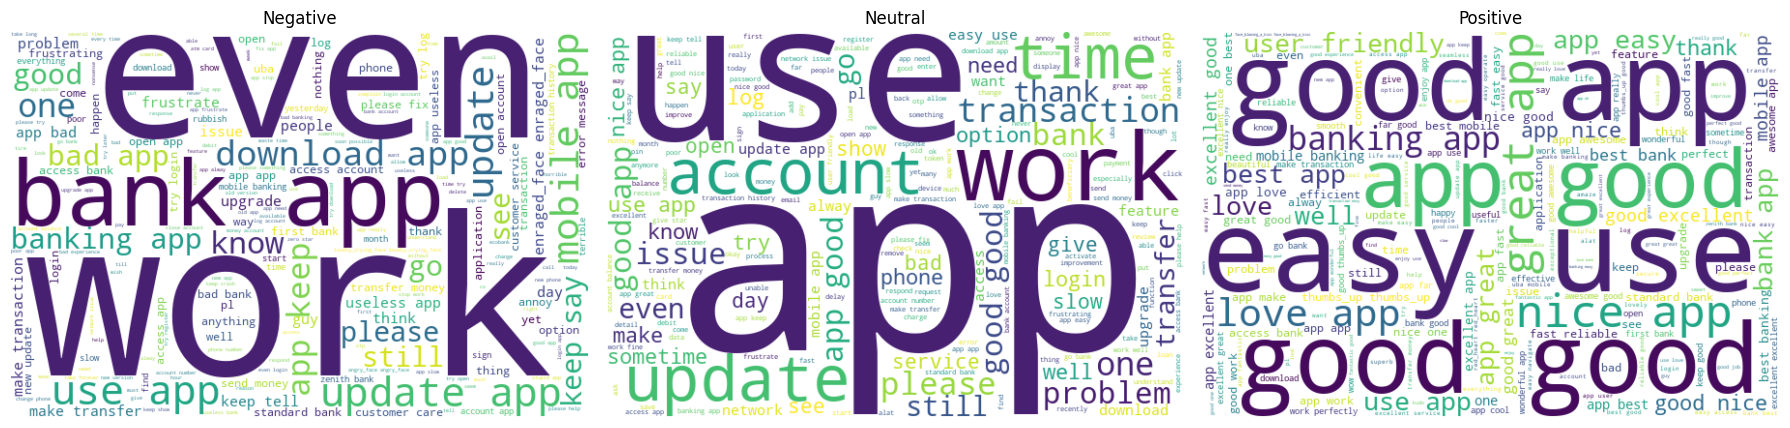

In [40]:
%pip install wordcloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt

sentiments = ["Negative", "Neutral", "Positive"]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, sentiment in zip(axes, sentiments):
    # Join all lemmatized tokens for this sentiment class into one text blob
    class_text = " ".join(
        df_clean.loc[df_clean["rating_derived_sentiment"] == sentiment, "lemmatized_tokens"]
        .apply(lambda tokens: " ".join(tokens))
    )

    wc = WordCloud(width=600, height=400, background_color="white", random_state=42).generate(class_text)

    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(sentiment)
    ax.axis("off")

plt.tight_layout()
plt.show()

### Interpreting the WordClouds: 
All three classes share several dominant, generic 
terms ("app," "use," "bank," "work"), reflecting the fact that this is a banking-app 
dataset regardless of sentiment. Unlike TF-IDF, a WordCloud reflects raw frequency 
within a class and cannot downweight words that are common everywhere, so shared 
vocabulary naturally appears large in all three clouds. The more informative signal 
is in the distinctive words: Negative shows terms like "frustrate," "useless," and 
"problem"; Positive shows "excellent," "reliable," and "friendly." Neutral shows no 
strong distinctive vocabulary, consistent with the weaker separability of this class 
found earlier in the TF-IDF feature analysis.

## Train-Test Split

A grouped split targeting 20% of the review-text groups for testing was used. Because the groups vary in size, the resulting row-level split was **80.51% for training and 19.49% for testing**.

The split was performed using `GroupShuffleSplit`, with normalized review text used as the grouping variable. This ensures that the same normalized review text does not appear in both the training and test sets.


In [41]:
from sklearn.model_selection import GroupShuffleSplit

# Group identical review texts together so the same text
# cannot appear in both the training and test sets
df_clean["group_key"] = (
    df_clean["content"]
    .str.lower()
    .str.strip()
)

print("Total rows:", len(df_clean))
print("Unique review-text groups:", df_clean["group_key"].nunique())

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(df_clean, groups=df_clean["group_key"]))

train_df = df_clean.iloc[train_idx].copy()
test_df = df_clean.iloc[test_idx].copy()

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

overlap = set(train_df["group_key"]) & set(test_df["group_key"])
print("Review-text groups appearing in both train and test:", len(overlap))

print("\nTrain sentiment distribution:")
print(train_df["rating_derived_sentiment"].value_counts(normalize=True).round(3))
print("\nTest sentiment distribution:")
print(test_df["rating_derived_sentiment"].value_counts(normalize=True).round(3))

Total rows: 333821
Unique review-text groups: 213784
Train shape: (268752, 11)
Test shape: (65069, 11)
Review-text groups appearing in both train and test: 0

Train sentiment distribution:
rating_derived_sentiment
Positive    0.625
Negative    0.309
Neutral     0.066
Name: proportion, dtype: float64

Test sentiment distribution:
rating_derived_sentiment
Positive    0.624
Negative    0.308
Neutral     0.068
Name: proportion, dtype: float64



## TF-IDF Feature Extraction

Machine-learning models cannot work directly with the preprocessed token
lists, so the lemmatized tokens are joined back into text strings. Term
Frequency-Inverse Document Frequency (TF-IDF) is then used to represent each
review numerically based on the importance of its words within the training
corpus.

The TF-IDF vectorizer is fitted only on the training data. The fitted
vectorizer is then used to transform the test data without refitting it.
This prevents information from the test set from influencing the learned
vocabulary or IDF weights.

A minimum document frequency of 10 is used to exclude extremely rare terms
that occur in fewer than 10 reviews. The vocabulary is capped at 5,000 terms
to keep the feature space manageable.

In [42]:
from sklearn.feature_extraction.text import TfidfVectorizer

train_df["final_text"] = train_df["lemmatized_tokens"].apply(lambda tokens: " ".join(tokens))
test_df["final_text"] = test_df["lemmatized_tokens"].apply(lambda tokens: " ".join(tokens))

vectorizer = TfidfVectorizer(max_features=5000, min_df=10)
X_train = vectorizer.fit_transform(train_df["final_text"])
X_test = vectorizer.transform(test_df["final_text"])

y_train = train_df["rating_derived_sentiment"]
y_test = test_df["rating_derived_sentiment"]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Vocabulary size:", len(vectorizer.get_feature_names_out()))

X_train shape: (268752, 4492)
X_test shape: (65069, 4492)
Vocabulary size: 4492


### Checking Vocabulary Quality

To verify the final vocabulary reflects meaningful terms rather than noise, the top and bottom terms by total TF-IDF weight are inspected below.

In [43]:
import numpy as np

# Sum each term's TF-IDF weight across all training documents.
# Unlike get_feature_names_out() alone (which is alphabetical),
# this ranks terms by actual importance in the corpus.
tfidf_sums = np.asarray(X_train.sum(axis=0)).flatten()
term_importance = list(zip(vectorizer.get_feature_names_out(), tfidf_sums))
term_importance.sort(key=lambda x: x[1], reverse=True)

print("Top 30 terms by total TF-IDF weight:")
for term, score in term_importance[:30]:
    print(f"{term}: {score:.2f}")

print("\nBottom 20 terms (least influential in the vocabulary):")
for term, score in term_importance[-20:]:
    print(f"{term}: {score:.2f}")

Top 30 terms by total TF-IDF weight:
good: 33541.96
app: 18892.26
not: 11003.46
excellent: 10696.19
great: 10164.59
nice: 8858.48
use: 6792.55
easy: 6761.35
love: 6445.33
bank: 6340.76
best: 5155.53
work: 4521.61
fast: 4001.18
bad: 3742.92
update: 3643.23
account: 3620.06
banking: 3512.17
transaction: 3418.05
cool: 3339.58
try: 2983.83
make: 2875.25
keep: 2821.39
service: 2791.00
perfect: 2719.73
time: 2700.69
reliable: 2691.83
ok: 2688.97
one: 2647.11
fantastic: 2639.03
like: 2608.91

Bottom 20 terms (least influential in the vocabulary):
nigerias: 3.35
intentionally: 3.33
conclusion: 3.31
jan: 3.27
facing: 3.27
22nd: 3.26
native: 3.26
reluctant: 3.23
determine: 3.23
closure: 3.22
ziva: 3.18
150k: 3.11
reminder: 3.11
dayi: 3.11
reversed: 3.03
creditor: 3.02
mais: 3.01
26th: 2.91
furthermore: 2.63
apologise: 2.62


## Baseline Model: Logistic Regression

A Logistic Regression classifier is trained as the baseline model. Because the
Neutral class is substantially smaller than the Negative and Positive classes,
`class_weight="balanced"` is used to give greater training importance to the
minority class rather than allowing the majority classes to dominate the
learning process.

Macro-F1 is used as the primary evaluation metric because it gives each
sentiment class equal weight, making it more informative than accuracy when
the classes are imbalanced.

In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score

# class_weight="balanced" adjusts for the uneven class sizes
# (Positive ~62%, Negative ~31%, Neutral ~7%) so the model doesn't
# learn to predict the majority class
model = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)

# Train on the TF-IDF features and rating-derived sentiment labels
model.fit(X_train, y_train)

# Predict sentiment on the held-out test set
y_pred = model.predict(X_test)

# Macro-F1 treats all three classes equally, regardless of size
macro_f1 = f1_score(y_test, y_pred, average="macro")
print("Macro-F1 score:", round(macro_f1, 4))

print("\nFull classification report:")
print(classification_report(y_test, y_pred))

Macro-F1 score: 0.6384

Full classification report:
              precision    recall  f1-score   support

    Negative       0.83      0.77      0.80     20037
     Neutral       0.17      0.41      0.24      4421
    Positive       0.92      0.82      0.87     40611

    accuracy                           0.78     65069
   macro avg       0.64      0.67      0.64     65069
weighted avg       0.85      0.78      0.81     65069



### Interpreting the Baseline Results
The model performs well on Positive and Negative classes (F1 of 0.87 and 0.80 respectively) but struggles substantially with Neutral (F1 of 0.24). This gap is consistent with the earlier observation that sentiment labels in this project are rating-derived rather than independently annotated: 3-star reviews often contain genuinely mixed language ("good app but crashes a lot") that overlaps heavily with the vocabulary of both Positive and Negative reviews, giving the model little distinct signal to identify Neutral cases. The low Neutral precision indicates that many reviews predicted as Neutral belong to another class. The use of class_weight="balanced" may contribute to this behavior, but its specific effect was not isolated in this experiment

### Confusion Matrix

The confusion matrix shows which sentiment classes the model tends to 
mix up. Given the weak Neutral performance above, this should reveal 
whether Neutral is primarily confused with Negative, Positive, or both.

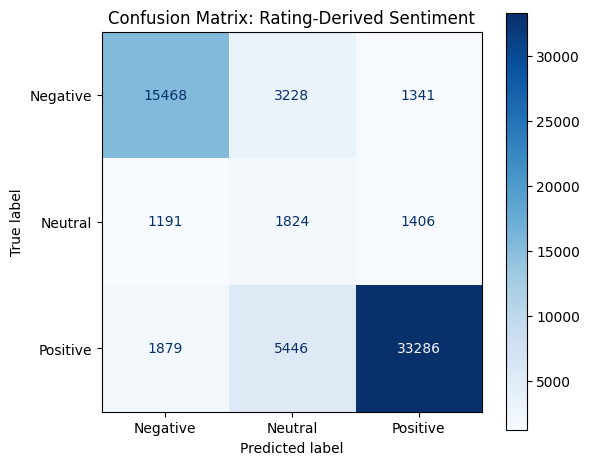

In [45]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# labels ensures a consistent class order (Negative, Neutral, Positive)
# rather than whatever order sklearn infers
labels = ["Negative", "Neutral", "Positive"]

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, labels=labels, cmap="Blues", ax=ax
)
plt.title("Confusion Matrix: Rating-Derived Sentiment")
plt.tight_layout()
plt.show()

### Interpreting the Confusion Matrix

The confusion matrix shows that the model has substantially more difficulty
with the Neutral class than with the Negative and Positive classes. Neutral
reviews that are misclassified are distributed in both directions, with the
model assigning some to Negative and others to Positive. This indicates that
the model does not show a strong one-directional confusion pattern for the
Neutral class.

The large number of Positive reviews predicted as Neutral also contributes to
the relatively low precision of the Neutral class. Overall, the matrix shows
that the model separates the two extreme sentiment classes more effectively
than the rating-derived Neutral class.

### Error Analysis: Reading Misclassified Reviews

To understand what drives Neutral misclassification, actual review 
text is examined for cases where the true label was Neutral but the 
model predicted Positive or Negative.

In [46]:
# Attach predictions back to the test set for inspection
test_df_with_preds = test_df.copy()
test_df_with_preds["predicted_sentiment"] = y_pred

# Case 1: True Neutral, predicted Positive
neutral_as_positive = test_df_with_preds[
    (test_df_with_preds["rating_derived_sentiment"] == "Neutral") &
    (test_df_with_preds["predicted_sentiment"] == "Positive")
]
print("=== True Neutral, predicted Positive (sample) ===")
print(neutral_as_positive[["content", "score", "rating_derived_sentiment",  "predicted_sentiment"]].sample(5, random_state=42))

# Case 2: True Neutral, predicted Negative
neutral_as_negative = test_df_with_preds[
    (test_df_with_preds["rating_derived_sentiment"] == "Neutral") &
    (test_df_with_preds["predicted_sentiment"] == "Negative")
]
print("\n=== True Neutral, predicted Negative (sample) ===")
print(neutral_as_negative[["content", "score", "rating_derived_sentiment",  "predicted_sentiment"]].sample(5, random_state=42))

=== True Neutral, predicted Positive (sample) ===
                                                  content  score  \
191871                     It's wow keep up the good work      3   
162094  I enjoy the services I get from this app. And ...      3   
100571                                          Wonderful      3   
62596                                              Uh. Hm      3   
284638                      Very nice app iam really aprt      3   

       rating_derived_sentiment predicted_sentiment  
191871                  Neutral            Positive  
162094                  Neutral            Positive  
100571                  Neutral            Positive  
62596                   Neutral            Positive  
284638                  Neutral            Positive  

=== True Neutral, predicted Negative (sample) ===
                                                  content  score  \
296326            For two days now i can't access the app      3   
179594  The app is good to go 

### Error Analysis Interpretation

Manual inspection of misclassified Neutral reviews reveals an important
limitation of the rating-derived target. Some reviews labelled Neutral contain
clearly positive or negative language. In such cases, the model's prediction
may be reasonable from the perspective of the review text, but it is still a
classification error relative to the rating-derived label.

Other Neutral reviews are primarily questions, requests, or descriptions of
app functionality rather than clear expressions of sentiment. These examples
illustrate that a three-class sentiment label derived solely from star ratings
does not always correspond directly to the sentiment expressed in the review
text.

This suggests that disagreement between the review text and the rating-derived
label is an important factor contributing to the model's difficulty with the
Neutral class. However, the error analysis does not by itself rule out
contributions from the model, preprocessing choices, or class imbalance.

### Top Features per Sentiment Class

The presence of emoji-derived tokens among the highly weighted features indicates that the Logistic Regression model uses emoji-related information when distinguishing between sentiment classes. However, feature importance alone does not establish that emoji conversion improves predictive performance or that the information represents independent signal.


Several of the strongest Neutral features, including terms such as `3star`
and `3stars`, suggest that the model is also learning from explicit
references to the rating within the review text. This is a useful finding
but also an important limitation because the target itself was derived from
the star rating.

In [47]:
import numpy as np

feature_names = vectorizer.get_feature_names_out()

# model.classes_ gives the class order matching model.coef_ rows
# For multiclass Logistic Regression, each row of coef_ corresponds to one class
for i, class_label in enumerate(model.classes_):
    coefs = model.coef_[i]
    top_positive_idx = np.argsort(coefs)[-15:][::-1]  # 15 words pushing MOST toward this class
    
    print(f"=== Top words predicting: {class_label} ===")
    for idx in top_positive_idx:
        print(f"{feature_names[idx]}: {coefs[idx]:.3f}")
    print()

=== Top words predicting: Negative ===
useless: 4.720
stupid: 4.251
worst: 3.856
terrible: 3.756
zero: 3.660
pathetic: 3.193
trash: 3.059
rubbish: 3.033
horrible: 2.984
poor: 2.823
enraged_face: 2.819
nonsense: 2.731
waste: 2.721
worse: 2.695
suck: 2.650

=== Top words predicting: Neutral ===
3star: 3.091
average: 2.567
3stars: 2.480
somewhat: 2.229
abuse: 2.086
amend: 2.072
14: 1.905
fair: 1.871
however: 1.852
priority: 1.828
language: 1.825
decent: 1.774
shortcut: 1.774
unfreeze: 1.765
eg: 1.736

=== Top words predicting: Positive ===
fantabulous: 2.263
tip: 2.259
notch: 2.206
best: 2.201
magnificent: 2.067
industry: 2.062
exellent: 2.049
thumbs_up_mediumdark_skin_tone: 2.027
pocket: 1.929
awesome: 1.924
thump: 1.920
exceptional: 1.919
heart_suit: 1.910
kudos: 1.886
swift: 1.830



### Interpreting Top Features per Class

The Negative class is driven by clearly negative vocabulary (useless, stupid, worst, terrible), and the Positive class by clearly positive vocabulary (fantabulous, magnificent, exceptional, awesome), including emoji-derived tokens (heart_suit, thumbs_up), confirming that the earlier decision to convert emojis to text contributes genuine signal rather than noise.

The Neutral class is more concerning. Several top features (3star, 3stars) indicate the model is partly learning to predict Neutral by detecting literal mentions of the star rating within the review text itself...

## Second Model: Multinomial Naive Bayes

Multinomial Naive Bayes is trained as the second classifier, using the same
TF-IDF features (`X_train`, `X_test`) and the same rating-derived sentiment
labels as Logistic Regression. This keeps the comparison fair, both models
see identical input.

In [48]:
from sklearn.naive_bayes import MultinomialNB

# Multinomial Naive Bayes works directly on the same TF-IDF matrix,
# no re-vectorizing needed
nb_model = MultinomialNB()

# Train on the same features and labels used for Logistic Regression
nb_model.fit(X_train, y_train)

# Predict sentiment on the same held-out test set
y_pred_nb = nb_model.predict(X_test)

# Macro-F1 for direct comparison with the Logistic Regression result
macro_f1_nb = f1_score(y_test, y_pred_nb, average="macro")
print("Naive Bayes Macro-F1 score:", round(macro_f1_nb, 4))

print("\nFull classification report (Naive Bayes):")
print(classification_report(y_test, y_pred_nb))

Naive Bayes Macro-F1 score: 0.5821

Full classification report (Naive Bayes):
              precision    recall  f1-score   support

    Negative       0.76      0.89      0.82     20037
     Neutral       0.40      0.02      0.03      4421
    Positive       0.89      0.91      0.90     40611

    accuracy                           0.84     65069
   macro avg       0.68      0.60      0.58     65069
weighted avg       0.82      0.84      0.82     65069



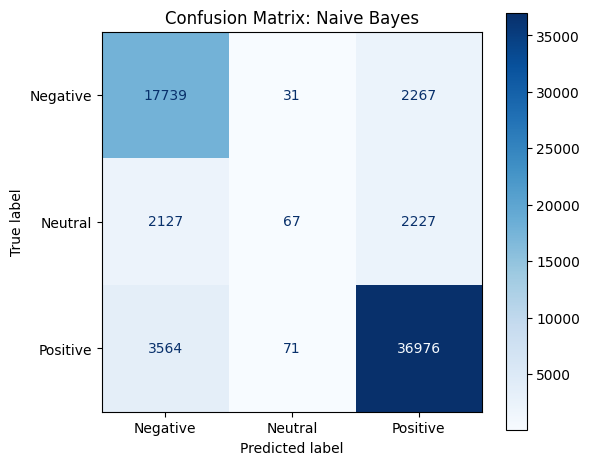

In [49]:
# Confusion matrix for Naive Bayes, same class order as Logistic Regression's matrix
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_nb, labels=labels, cmap="Blues", ax=ax
)
plt.title("Confusion Matrix: Naive Bayes")
plt.tight_layout()
plt.show()

### Interpreting the Naive Bayes Results

Naive Bayes achieves higher overall accuracy than Logistic Regression (0.84 vs 0.78) 
and slightly stronger performance on both Negative and Positive (F1 of 0.82 and 0.90, 
compared to 0.80 and 0.87). However, its Neutral-class recall collapses to 0.02, 
meaning the model correctly identifies almost none of the actual Neutral reviews, 
out of 4,421 Neutral reviews in the test set, only 67 were correctly predicted.

This gap is best explained by a key difference between the two models: Logistic 
Regression was trained with `class_weight="balanced"`, which forces the model to 
give the minority Neutral class more weight during training. `MultinomialNB` has 
no equivalent parameter, so with no correction for class imbalance, it defaults 
heavily toward the majority classes (Positive and Negative), effectively treating 
Neutral as noise.

NNaive Bayes achieved higher overall accuracy, but this occurs alongside extremely poor performance on the Neutral class. Its high accuracy is therefore strongly influenced by its successful predictions on the majority Negative and Positive classes, rather than indicating balanced performance across all three sentiment classes.


## Model Comparison

The table below compares Logistic Regression and Multinomial Naive Bayes on
the same test set. Precision and Recall are macro-averaged (unweighted mean
across all three classes) to match Macro-F1, since accuracy alone would
favor whichever model best predicts the majority Positive class, regardless
of how it handles Negative or Neutral.

In [50]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Multinomial Naive Bayes"],
    "Accuracy": [0.78, 0.84],
    "Precision (macro)": [0.64, 0.68],
    "Recall (macro)": [0.67, 0.60],
    "Macro-F1": [0.6384, 0.5821]
})

comparison

,Model,Accuracy,Precision (macro),Recall (macro),Macro-F1
0,Logistic Regression,0.78,0.64,0.67,0.6384
1,Multinomial Naive Bayes,0.84,0.68,0.60,0.5821


### Model With Better Performance

Naive Bayes has higher accuracy (0.84 vs 0.78) and higher macro precision (0.68 vs 0.64), 
but Logistic Regression has higher macro recall (0.67 vs 0.60) and, most importantly, a 
higher Macro-F1 (0.6384 vs 0.5821).

Macro-F1 is treated as the primary metric for this project because it weights all three 
sentiment classes equally, rather than letting the large Positive class dominate the score. 
By that standard, **Logistic Regression is the better-performing model**, specifically 
because it remains usable for the Neutral class (F1 = 0.24) while Naive Bayes effectively 
fails on it (F1 = 0.03). Naive Bayes' higher accuracy is a product of ignoring the minority 
class almost entirely, not a sign of stronger overall performance.

This does not mean Logistic Regression solves the Neutral-class problem, only that it 
handles it far less badly than Naive Bayes does. Both models perform substantially worse on the Neutral class than on the Negative and Positive classes, although the extent of the weakness differs between models. Several factors may contribute to this pattern, including the strong class imbalance in the dataset, the behavior of the individual models, and ambiguity introduced by the rating-derived labeling scheme. Because Neutral labels are defined from a 3-star rating rather than from independent human annotation of textual sentiment, some reviews may contain language that appears positive or negative even though the assigned label is Neutral.


## Methodology and Limitations

This project involved a number of deliberate design decisions and 
uncovered several limitations worth stating explicitly, both for 
transparency and to guide any future extension of this work.

**Sentiment labels are rating-derived, not independently annotated.**
The dataset does not include human-annotated sentiment. Labels used 
throughout this project (`rating_derived_sentiment`) were constructed 
by grouping the 1–5 star rating into three categories (1–2 = Negative, 
3 = Neutral, 4–5 = Positive). This is a common and defensible approach, 
but it means the model is learning to predict a customer's star rating 
category from text, not an independently verified sentiment. Star 
ratings and review text do not always agree, and this disagreement is 
the primary driver of the model's weaker performance on the Neutral 
class (see below).

**Duplicate handling was a judgment call, not an established fact.**
Very short reviews (fewer than five words, e.g., "Good," "Excellent") 
were retained even when repeated verbatim, because duplicate provenance 
could not be established from the available data,  repeated short 
reviews may represent independent customer submissions rather than 
duplicated records. Exact duplicates among longer reviews (five or more 
words) were reduced to one occurrence, based on year, review text, 
rating, and bank. This reduced the dataset from 334,292 to 333,821 rows.

**Train/test split was grouped, not row-random, to prevent leakage.** Because many short reviews repeat verbatim across the dataset, a standard random split could place identical text in both the training and test sets, inflating apparent performance. To address this, rows sharing identical review text (after lowercasing and trimming whitespace) were grouped, and each group was assigned entirely to one side of an 80/20 split (confirmed: zero groups appeared in both sets).

**The standard English stopword list may not fully suit this dataset.**
Reviews are written in a mix of standard English, Nigerian English, 
and Nigerian Pidgin. A generic NLTK 
English stopword list was used, with negation words (no, nor, not, 
never, cannot) explicitly preserved to protect sentiment-bearing 
negations. This list was not customized for regional vocabulary, which 
is a limitation for a dataset drawn specifically from Nigerian banking 
app reviews.

**Vocabulary was filtered to reduce noise.**
An initial TF-IDF vocabulary of 5,000 terms included a meaningful amount of low-value noise: one-off emoji-derived tokens (e.g., roller_coaster, mending_heart) and stray foreign-language fragments. Setting min_df=10 (a term must appear in at least 10 reviews) reduced the vocabulary to 4,492 more broadly meaningful terms.

**Model performance is strong overall but notably weaker on the 
Neutral class.** The baseline Logistic Regression model achieved a 
macro-F1 of 0.64, with strong performance on Negative (F1 = 0.80) and 
Positive (F1 = 0.87) but weak performance on Neutral (F1 = 0.24). 
Manual error analysis found two contributing causes: (1) many Neutral 
(3-star) reviews contain clearly positive or negative language ("Love 
the service," "I hate this honoring fee thing"), meaning the model's 
"errors" often reflect genuine disagreement between the text and its 
rating-derived label, rather than a modeling failure; and (2) some 
Neutral reviews are not sentiment statements at all, but questions or 
feature requests ("Can I open an account using the app?"), which carry 
little sentiment signal for the model to use.

A target-related feature issue was identified in the Neutral class. Some reviews explicitly mention their star rating, such as '3 stars', while the sentiment label itself is derived from that rating. These terms therefore provide the model with a direct textual proxy for the target rather than independent evidence of neutral sentiment.

**Overall conclusion.** Between the two models tested, Logistic Regression is the better performer 
on this task, based on Macro-F1 (see Model Comparison above), primarily because it remains 
usable for the Neutral class while Naive Bayes does not. Both models perform well at 
distinguishing clearly positive from clearly negative reviews, which is the strongest and 
most reliable signal in this dataset. Both models perform substantially worse on the Neutral class, although the extent and possible causes differ. The rating-derived labeling scheme contributes ambiguity, while class imbalance and model-specific behavior also affect Neutral-class performance

A realistic practical application for this model is triaging incoming customer reviews for a 
Nigerian banking app: automatically flagging newly posted Negative reviews for faster follow-up 
by a support or product team, rather than requiring someone to read every review manually. Given 
the model's demonstrated weakness on Neutral, it would need to be paired with human review for 
borderline cases rather than deployed as a fully automated triage system.